# Netflix Movies & TV Shows — Data Analysis

**Author:** Arjun Gyawali
**Course:** CS4379G Data Analysis & Visualization — Assignment 1  
**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) (`netflix_titles.csv`)

---

## Problem Statement

Netflix has grown into one of the world's largest streaming platforms. Understanding how its content library has evolved can reveal strategic shifts in acquisition and production. This notebook investigates two questions:

1. **How has the number of titles added to Netflix changed over time (by year)?**
2. **Do Movies and TV Shows differ in their ratings distribution?**

## 1) Imports and Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

# Paths (relative — notebook lives in notebooks/, data in data/netflix/)
DATA_DIR = Path("../data/netflix")
CSV_PATH = DATA_DIR / "netflix_titles.csv"

## 2) Load Data

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CSV_PATH}.\n"
        "Download netflix_titles.csv from Kaggle and place it in data/netflix/."
    )

df = pd.read_csv(CSV_PATH)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 8807 rows x 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Data Dictionary

| Column | Description |
|---|---|
| `show_id` | Unique identifier for each title |
| `type` | Whether the title is a **Movie** or **TV Show** |
| `title` | Name of the movie or show |
| `director` | Director(s) of the title |
| `cast` | Main actors/actresses |
| `country` | Country or countries of production |
| `date_added` | Date the title was added to Netflix |
| `release_year` | Original release year of the title |
| `rating` | Content rating (e.g., TV-MA, PG-13, R) |
| `duration` | Length in minutes (Movies) or number of seasons (TV Shows) |
| `listed_in` | Genre categories the title belongs to |
| `description` | Brief summary of the title |

## 3) Quick Checks

In [3]:
df.shape

(8807, 12)

In [4]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# Check for missing values
df.isna().sum().sort_values(ascending=False).head(12)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [7]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate show_ids: {df['show_id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate show_ids: 0


## 4) Data Cleaning

We clean the data by:
- Parsing `date_added` as datetime and extracting `year_added`
- Extracting numeric duration from the `duration` column
- Stripping whitespace from string columns

In [8]:
def clean_netflix_data(dataframe):
    """
    Clean the Netflix titles DataFrame.
    
    Steps:
    - Strip whitespace from all string columns
    - Parse date_added to datetime and extract year_added
    - Extract numeric duration (minutes for Movies, seasons for TV Shows)
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        Raw Netflix titles DataFrame.
    
    Returns
    -------
    pd.DataFrame
        Cleaned copy of the DataFrame with new columns.
    """
    df_clean = dataframe.copy()
    
    # Strip whitespace from string columns
    str_cols = df_clean.select_dtypes(include="object").columns
    for col in str_cols:
        df_clean[col] = df_clean[col].str.strip()
    
    # Parse date_added and extract year
    df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")
    df_clean["year_added"] = df_clean["date_added"].dt.year
    
    # Extract numeric duration
    df_clean["duration_num"] = (
        df_clean["duration"]
        .str.extract(r"(\d+)", expand=False)
        .astype(float)
    )
    
    return df_clean


df = clean_netflix_data(df)
print("Cleaning complete.")
df[["title", "type", "date_added", "year_added", "duration", "duration_num"]].head(10)

Cleaning complete.


,title,type,date_added,year_added,duration,duration_num
0,Dick Johnson Is Dead,Movie,2021-09-25,2021.0,90 min,90.0
1,Blood & Water,TV Show,2021-09-24,2021.0,2 Seasons,2.0
2,Ganglands,TV Show,2021-09-24,2021.0,1 Season,1.0
3,Jailbirds New Orleans,TV Show,2021-09-24,2021.0,1 Season,1.0
4,Kota Factory,TV Show,2021-09-24,2021.0,2 Seasons,2.0
5,Midnight Mass,TV Show,2021-09-24,2021.0,1 Season,1.0
6,My Little Pony: A New Generation,Movie,2021-09-24,2021.0,91 min,91.0
7,Sankofa,Movie,2021-09-24,2021.0,125 min,125.0
8,The Great British Baking Show,TV Show,2021-09-24,2021.0,9 Seasons,9.0
9,The Starling,Movie,2021-09-24,2021.0,104 min,104.0


## 5) Analysis 1: Titles Added to Netflix Over Time

We group by `year_added` and count titles, split by content type (Movie vs TV Show), to see how Netflix's catalog growth has changed over the years.

In [9]:
# Grouped summary: titles added per year, split by type
yearly_type = (
    df.dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .unstack(fill_value=0)
)
yearly_type["Total"] = yearly_type.sum(axis=1)
yearly_type.tail(10)

type,Movie,TV Show,Total
year_added,,,
2012.0,3,0,3
2013.0,6,5,11
2014.0,19,5,24
2015.0,56,26,82
2016.0,253,176,429
2017.0,839,349,1188
2018.0,1237,412,1649
2019.0,1424,592,2016
2020.0,1284,595,1879


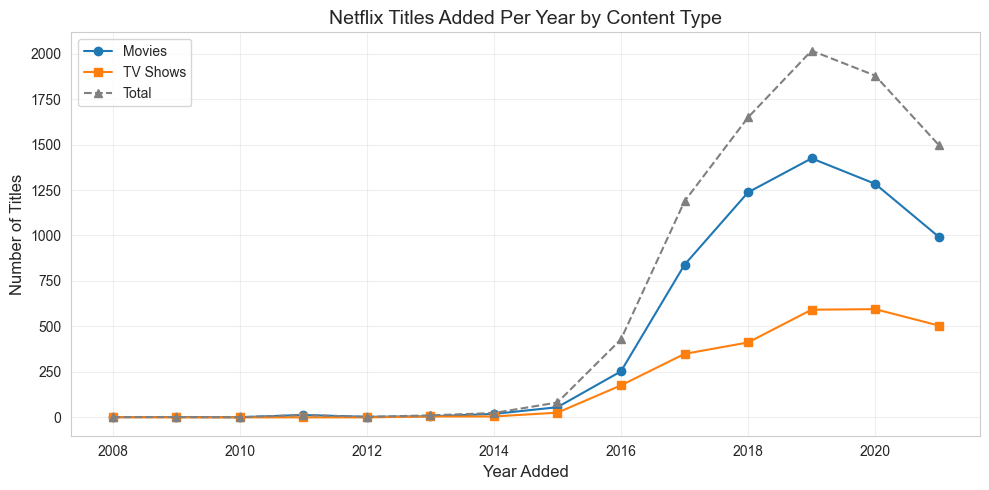

In [10]:
# --- Visualization 1: Line chart — Titles added per year (relationship plot) ---

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly_type.index, yearly_type["Movie"], marker="o", label="Movies")
ax.plot(yearly_type.index, yearly_type["TV Show"], marker="s", label="TV Shows")
ax.plot(yearly_type.index, yearly_type["Total"], marker="^", linestyle="--", color="gray", label="Total")

ax.set_xlabel("Year Added", fontsize=12)
ax.set_ylabel("Number of Titles", fontsize=12)
ax.set_title("Netflix Titles Added Per Year by Content Type", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** Netflix's content additions grew steadily from 2015, with over 1,600 titles added in 2018 and peaking at roughly 2,000 in 2019. After 2020, there is a notable decline, possibly due to the impact of COVID-19 on production. Movies consistently make up the majority of additions each year, but TV Shows have grown as a proportion over time.

## 6) Analysis 2: Ratings Distribution: Movies vs TV Shows

We compare how content ratings (e.g., TV-MA, TV-14, PG-13) are distributed across Movies and TV Shows to see if there are differences in audience targeting.

In [11]:
# Grouped summary: count of titles by rating and type
rating_type = (
    df.dropna(subset=["rating"])
    .groupby(["rating", "type"])
    .size()
    .unstack(fill_value=0)
)

# Sort by total and keep top 8 for readability
rating_type["Total"] = rating_type.sum(axis=1)
top_ratings = rating_type.sort_values("Total", ascending=False).head(8).drop(columns="Total")
top_ratings

type,Movie,TV Show
rating,,
TV-MA,2062,1145
TV-14,1427,733
TV-PG,540,323
R,797,2
PG-13,490,0
TV-Y7,139,195
TV-Y,131,176
PG,287,0


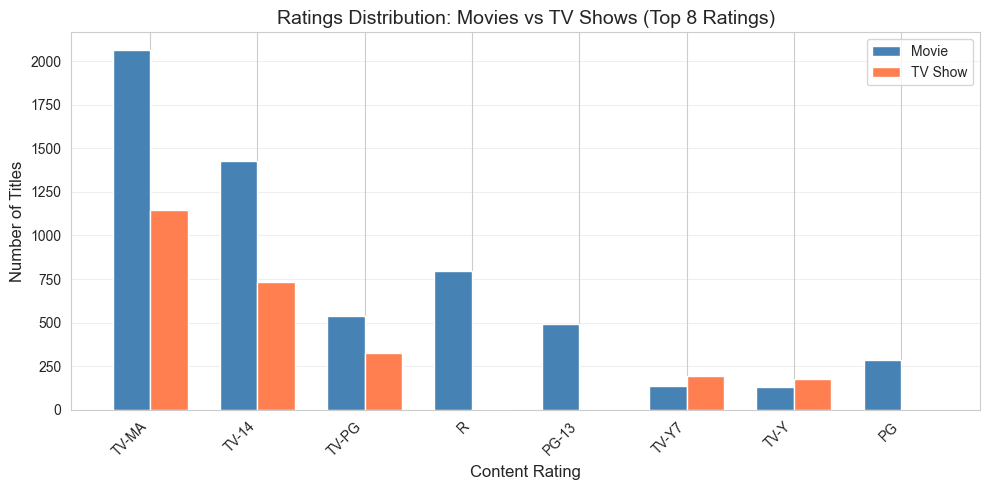

In [12]:
# --- Visualization 2: Grouped bar chart — Ratings by type (distribution plot) ---

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(top_ratings.index))
width = 0.35

ax.bar(x - width/2, top_ratings["Movie"], width, label="Movie", color="steelblue")
ax.bar(x + width/2, top_ratings["TV Show"], width, label="TV Show", color="coral")

ax.set_xlabel("Content Rating", fontsize=12)
ax.set_ylabel("Number of Titles", fontsize=12)
ax.set_title("Ratings Distribution: Movies vs TV Shows (Top 8 Ratings)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top_ratings.index, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Interpretation:** TV-MA is the dominant rating for both Movies and TV Shows, reflecting Netflix's focus on mature-audience content. However, the distribution differs: Movies are spread across a wider range of ratings (TV-MA, TV-14, TV-PG, R, PG-13), while TV Shows are heavily concentrated in TV-MA and TV-14. This suggests Netflix's TV Show catalog skews more toward older audiences, whereas the movie library caters to a broader range of age groups.

## 7) Summary of Findings

1. **Content growth peaked around 2019-2020.** Netflix rapidly expanded its catalog from 2015 to 2019, adding over 1,500 titles in peak years. The decline after 2020 may reflect a strategic shift toward original content over licensed titles, or incomplete data for recent years.

2. **Movies dominate the catalog (~2:1 over TV Shows)** and make up the majority of additions every year, though TV Shows have been growing steadily as a share.

3. **TV-MA is the most common rating for both content types**, but Movies have a wider spread of ratings while TV Shows cluster around TV-MA and TV-14, indicating the show catalog leans more heavily toward mature audiences.

4. **Missing data is present** in several columns (notably `director`, `cast`, and `country`), but does not significantly affect these analyses since we focused on `date_added`, `type`, and `rating`.

## 8) Reproducibility Check

Run **Kernel -> Restart & Run All** to verify this notebook executes cleanly from top to bottom.